<a href="https://colab.research.google.com/github/LunaGar1/Practica3-Vision-e-IA/blob/main/1_descarga_dataset_masati.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Reto 1: Descarga del Dataset MASATI

Montar google drive

In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Extraer y explorar el Dataset

In [ ]:
import zipfile
import shutil
from pathlib import Path

zip_path = '/content/drive/MyDrive/VisionComputadorIA/MASATI.zip'
extract_path = '/content/MASATI'

if not os.path.exists(extract_path):
    print(f"Extrayendo dataset de {zip_path}...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Dataset extraído exitosamente")
else:
    print(f"Dataset ya existe en {extract_path}")

Dataset ya existe en /content/MASATI


Entender la estructura del dataset

In [ ]:
import glob
from collections import defaultdict

print("\nCATEGORÍAS DE IMÁGENES")

categories = [d for d in os.listdir(masati_root)
              if os.path.isdir(os.path.join(masati_root, d))]

for category in sorted(categories):
    cat_path = os.path.join(masati_root, category)
    images = glob.glob(os.path.join(cat_path, '*.jpg')) + \
             glob.glob(os.path.join(cat_path, '*.png'))
    if len(images) > 0:
        print(f"\n{category}: {len(images)} imágenes")

print("\nANOTACIONES")
for root, dirs, files in os.walk(masati_root):
    if 'xml' in root.lower() or any(f.endswith('.xml') for f in files):
        xml_files = [f for f in files if f.endswith('.xml')]
        if len(xml_files) > 0:
            print(f"Carpeta: {root}")
            print(f"Archivos XML: {len(xml_files)}")


CATEGORÍAS DE IMÁGENES

ANOTACIONES
Carpeta: /content/MASATI/MASATI-v2/coast_ship_labels
Archivos XML: 1037
Carpeta: /content/MASATI/MASATI-v2/multi_labels
Archivos XML: 304
Carpeta: /content/MASATI/MASATI-v2/ship_labels
Archivos XML: 1027


In [ ]:
import xml.etree.ElementTree as ET
import numpy as np
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
import random

def parse_xml_annotation(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()

    filename = root.find('filename').text
    width = int(root.find('size/width').text)
    height = int(root.find('size/height').text)

    boxes = []
    for obj in root.findall('object'):
        label = obj.find('name').text
        bndbox = obj.find('bndbox')
        xmin = int(float(bndbox.find('xmin').text))
        ymin = int(float(bndbox.find('ymin').text))
        xmax = int(float(bndbox.find('xmax').text))
        ymax = int(float(bndbox.find('ymax').text))

        boxes.append({
            'label': label,
            'xmin': xmin,
            'ymin': ymin,
            'xmax': xmax,
            'ymax': ymax,
            'width': xmax - xmin,
            'height': ymax - ymin
        })

    return {
        'filename': filename,
        'width': width,
        'height': height,
        'boxes': boxes
    }

xml_dir = None
for root, dirs, files in os.walk(masati_root):
    if any(f.endswith('.xml') for f in files):
        xml_dir = root
        break

if xml_dir:
    print(f"Carpeta XML encontrada: {xml_dir}")
    xml_files = glob.glob(os.path.join(xml_dir, '*.xml'))
    print(f"Total de archivos XML: {len(xml_files)}")
else:
    print("No se encontraron archivos XML")

Carpeta XML encontrada: /content/MASATI/MASATI-v2/coast_ship_labels
Total de archivos XML: 1037


Visualizar Imágenes aleatorias con Bounding Boxes

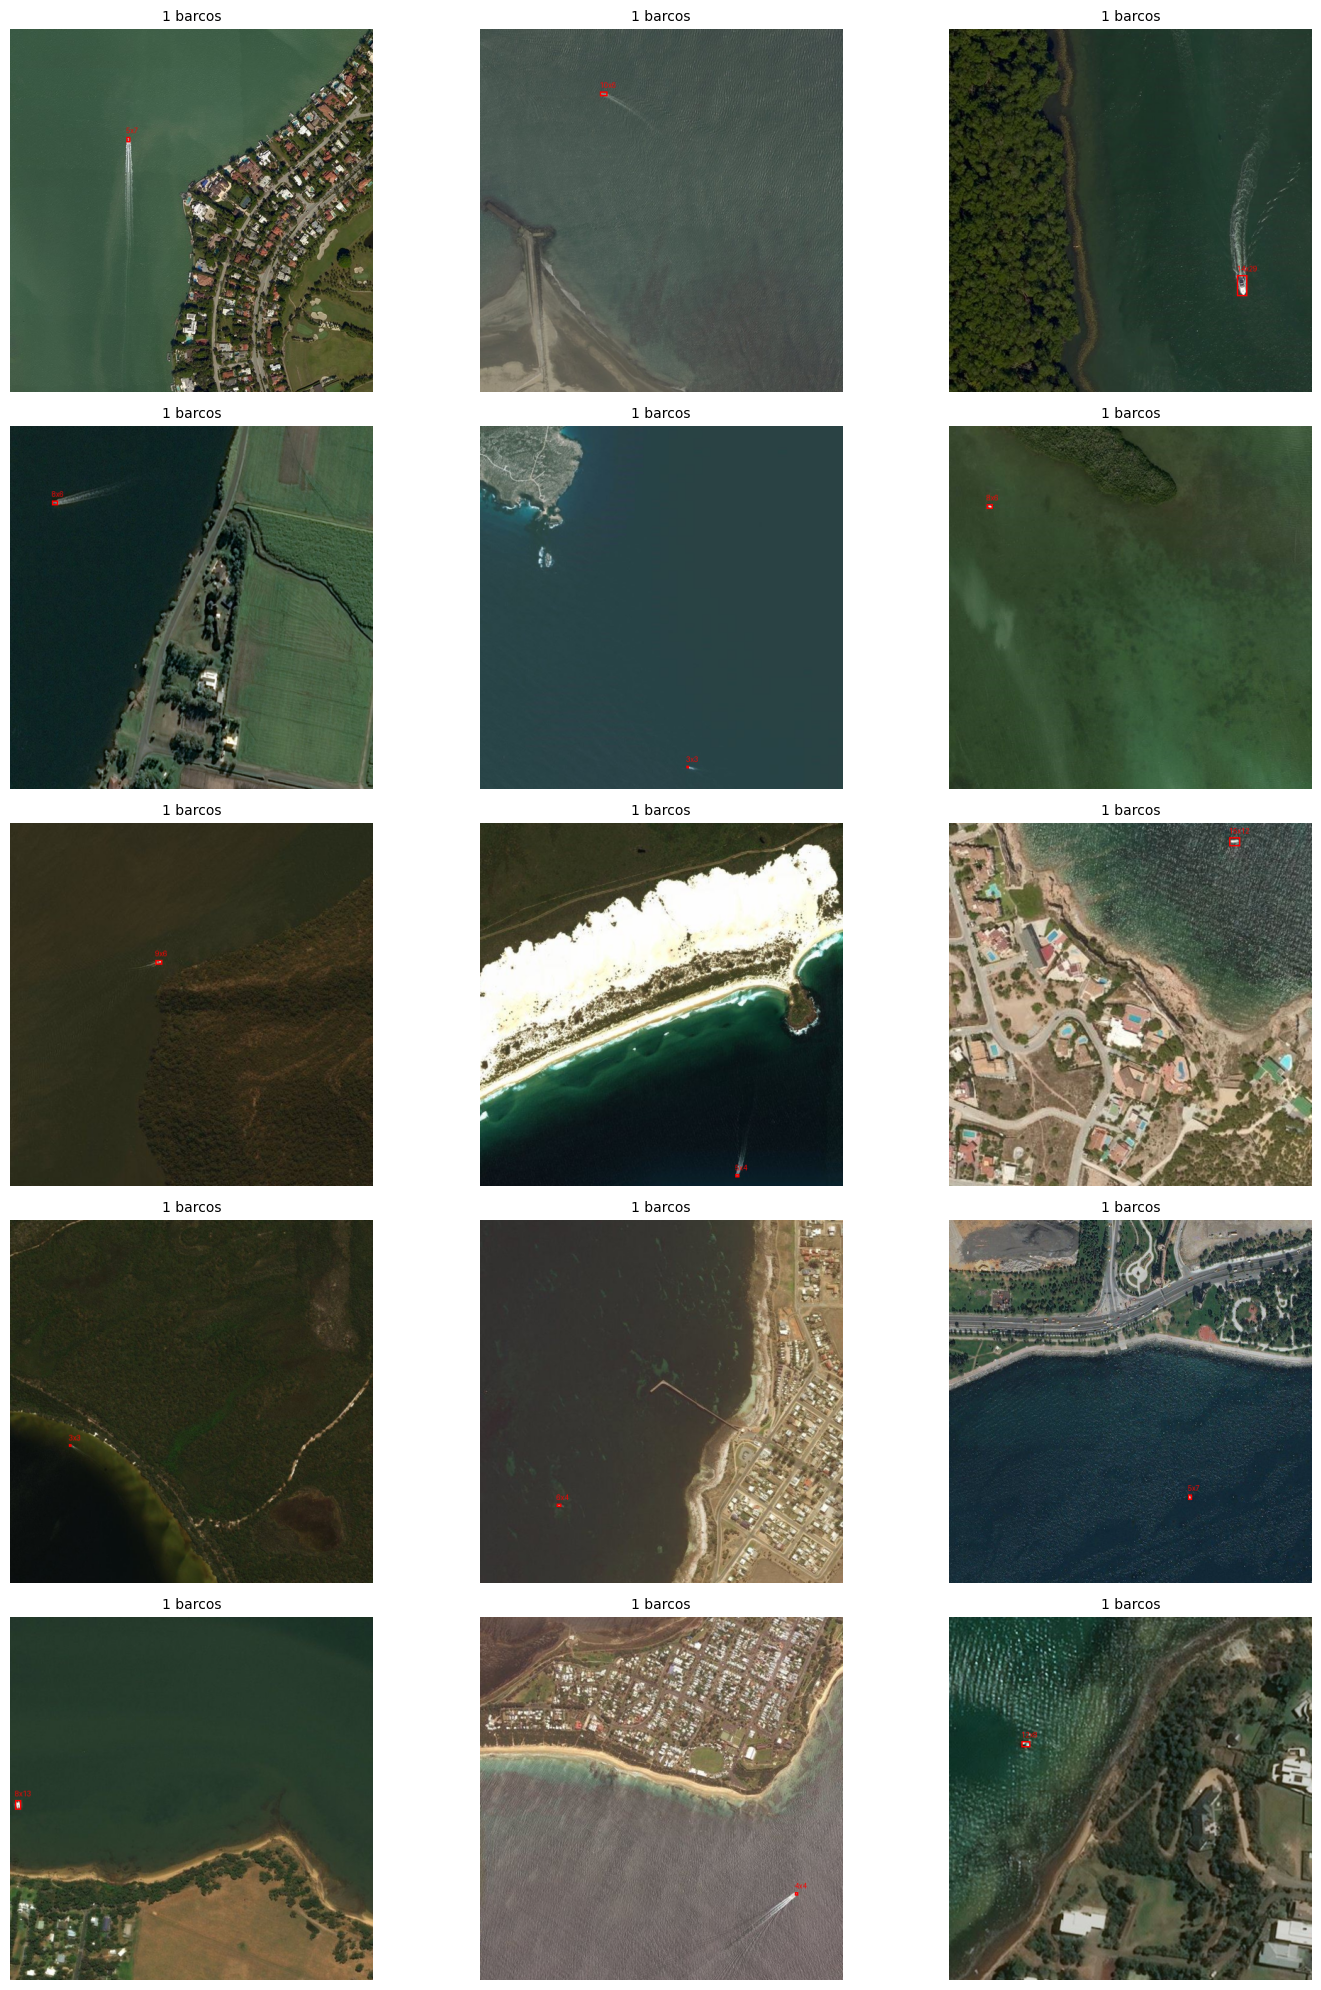

✓ Visualización guardada


In [ ]:
def find_image_path(filename, masati_root):
    for root, dirs, files in os.walk(masati_root):
        if filename in files:
            return os.path.join(root, filename)
    return None

def draw_boxes_on_image(image_path, boxes, title=""):
    img = Image.open(image_path).convert('RGB')
    draw = ImageDraw.Draw(img)

    colors = ['red', 'blue', 'green', 'yellow', 'cyan', 'magenta']

    for i, box in enumerate(boxes):
        color = colors[i % len(colors)]
        coords = [(box['xmin'], box['ymin']), (box['xmax'], box['ymax'])]
        draw.rectangle(coords, outline=color, width=2)

        label = f"{box['width']}x{box['height']}"
        draw.text((box['xmin'], max(0, box['ymin']-15)), label, fill=color)

    return img

if xml_dir:
    xml_files = glob.glob(os.path.join(xml_dir, '*.xml'))
    random.shuffle(xml_files)

    num_to_show = min(15, len(xml_files))
    fig, axes = plt.subplots(5, 3, figsize=(15, 20))
    axes = axes.flatten()

    for idx, xml_path in enumerate(xml_files[:num_to_show]):
        try:

            annot = parse_xml_annotation(xml_path)

            img_path = find_image_path(annot['filename'], masati_root)

            if img_path and os.path.exists(img_path):

                img = draw_boxes_on_image(img_path, annot['boxes'])

                axes[idx].imshow(img)
                axes[idx].set_title(f"{len(annot['boxes'])} barcos", fontsize=10)
                axes[idx].axis('off')
        except Exception as e:
            axes[idx].text(0.5, 0.5, f"Error: {str(e)[:30]}", ha='center')
            axes[idx].axis('off')

    for idx in range(num_to_show, len(axes)):
        axes[idx].axis('off')

    plt.tight_layout()
    plt.savefig('/content/muestras_dataset.png', dpi=100, bbox_inches='tight')
    plt.show()
    print(f"✓ Visualización guardada")
else:
    print("No se puede visualizar sin archivos XML")

Estadísticas y Análisis del Dataset

ESTADÍSTICAS DEL DATASET MASATI

IMÁGENES:
  Total de imágenes: 1037
  Imágenes sin barcos: 0
  Imágenes con barcos: 1037

BARCOS:
  Total de barcos etiquetados: 1061
  Promedio de barcos por imagen: 1.02
  Max barcos en una imagen: 12
  Min barcos en una imagen: 1

TAMAÑO DE BOUNDING BOXES:
  Ancho promedio: 9.86 px
  Altura promedio: 11.07 px
  Ancho rango: [1, 52] px
  Altura rango: [2, 72] px


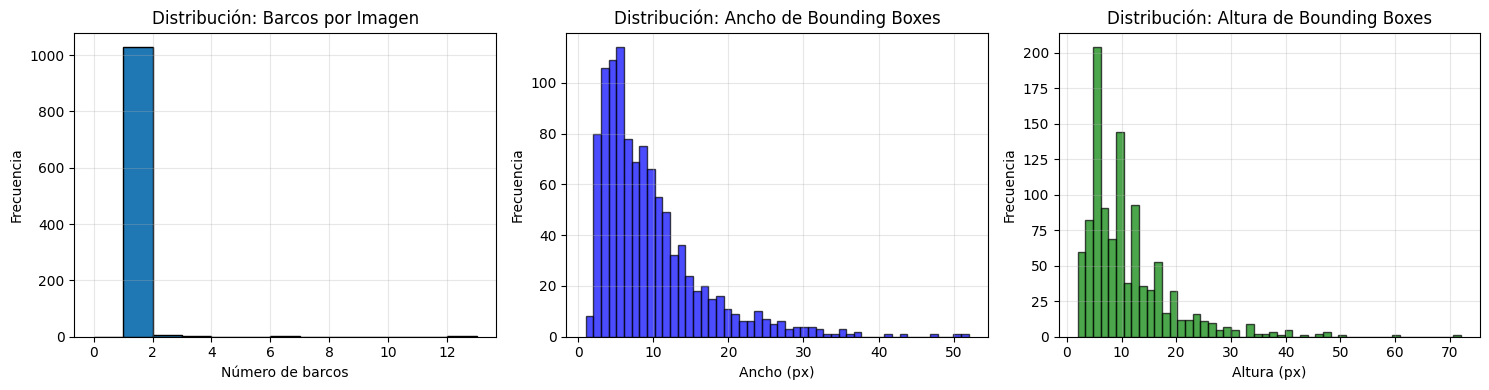


✓ Gráficos guardados


In [ ]:
import pandas as pd

if xml_dir:
    xml_files = glob.glob(os.path.join(xml_dir, '*.xml'))

    total_images = len(xml_files)
    total_boxes = 0
    images_with_no_ships = 0
    images_with_ships = 0
    box_widths = []
    box_heights = []
    ships_per_image = []

    for xml_path in xml_files:
        try:
            annot = parse_xml_annotation(xml_path)
            num_boxes = len(annot['boxes'])

            total_boxes += num_boxes
            ships_per_image.append(num_boxes)

            if num_boxes == 0:
                images_with_no_ships += 1
            else:
                images_with_ships += 1

            for box in annot['boxes']:
                box_widths.append(box['width'])
                box_heights.append(box['height'])
        except:
            pass

    print("ESTADÍSTICAS DEL DATASET MASATI")
    print(f"\nIMÁGENES:")
    print(f"  Total de imágenes: {total_images}")
    print(f"  Imágenes sin barcos: {images_with_no_ships}")
    print(f"  Imágenes con barcos: {images_with_ships}")

    print(f"\nBARCOS:")
    print(f"  Total de barcos etiquetados: {total_boxes}")
    print(f"  Promedio de barcos por imagen: {total_boxes/total_images:.2f}")
    print(f"  Max barcos en una imagen: {max(ships_per_image)}")
    print(f"  Min barcos en una imagen: {min(ships_per_image)}")

    if len(box_widths) > 0:
        print(f"\nTAMAÑO DE BOUNDING BOXES:")
        print(f"  Ancho promedio: {np.mean(box_widths):.2f} px")
        print(f"  Altura promedio: {np.mean(box_heights):.2f} px")
        print(f"  Ancho rango: [{min(box_widths)}, {max(box_widths)}] px")
        print(f"  Altura rango: [{min(box_heights)}, {max(box_heights)}] px")

        fig, axes = plt.subplots(1, 3, figsize=(15, 4))

        axes[0].hist(ships_per_image, bins=range(0, max(ships_per_image)+2), edgecolor='black')
        axes[0].set_xlabel('Número de barcos')
        axes[0].set_ylabel('Frecuencia')
        axes[0].set_title('Distribución: Barcos por Imagen')
        axes[0].grid(True, alpha=0.3)

        axes[1].hist(box_widths, bins=50, edgecolor='black', alpha=0.7, color='blue')
        axes[1].set_xlabel('Ancho (px)')
        axes[1].set_ylabel('Frecuencia')
        axes[1].set_title('Distribución: Ancho de Bounding Boxes')
        axes[1].grid(True, alpha=0.3)

        axes[2].hist(box_heights, bins=50, edgecolor='black', alpha=0.7, color='green')
        axes[2].set_xlabel('Altura (px)')
        axes[2].set_ylabel('Frecuencia')
        axes[2].set_title('Distribución: Altura de Bounding Boxes')
        axes[2].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig('/content/estadisticas_dataset.png', dpi=100, bbox_inches='tight')
        plt.show()
        print("\n✓ Gráficos guardados")

Análisis de Calidad de Anotaciones

In [ ]:
if xml_dir:
    xml_files = glob.glob(os.path.join(xml_dir, '*.xml'))

    print("ANÁLISIS DE CALIDAD DE ANOTACIONES")

    boxes_touching_edge = 0
    boxes_very_small = 0
    boxes_very_large = 0
    total_boxes_analyzed = 0
    aspect_ratios = []

    sample_size = min(100, len(xml_files))
    for xml_path in xml_files[:sample_size]:
        try:
            annot = parse_xml_annotation(xml_path)
            img_w, img_h = annot['width'], annot['height']

            for box in annot['boxes']:
                total_boxes_analyzed += 1
                w, h = box['width'], box['height']

                if box['xmin'] < 5 or box['ymin'] < 5 or \
                   box['xmax'] > img_w - 5 or box['ymax'] > img_h - 5:
                    boxes_touching_edge += 1

                if min(w, h) < 20:
                    boxes_very_small += 1

                if max(w, h) > 500:
                    boxes_very_large += 1

                if min(w, h) > 0:
                    aspect_ratios.append(max(w, h) / min(w, h))
        except:
            pass

    print(f"\nPrimeras {sample_size} imágenes:")
    print(f"  Total de boxes analizados: {total_boxes_analyzed}")
    if total_boxes_analyzed > 0:
        print(f"  Boxes tocando el borde: {boxes_touching_edge} ({100*boxes_touching_edge/total_boxes_analyzed:.1f}%)")
        print(f"  Boxes muy pequeños (<20px): {boxes_very_small} ({100*boxes_very_small/total_boxes_analyzed:.1f}%)")
        print(f"  Boxes muy grandes (>500px): {boxes_very_large} ({100*boxes_very_large/total_boxes_analyzed:.1f}%)")
        if len(aspect_ratios) > 0:
            print(f"  Aspect ratio promedio: {np.mean(aspect_ratios):.2f}")
            print(f"  Aspect ratio rango: [{min(aspect_ratios):.2f}, {max(aspect_ratios):.2f}]")

ANÁLISIS DE CALIDAD DE ANOTACIONES

Primeras 100 imágenes:
  Total de boxes analizados: 100
  Boxes tocando el borde: 0 (0.0%)
  Boxes muy pequeños (<20px): 95 (95.0%)
  Boxes muy grandes (>500px): 0 (0.0%)
  Aspect ratio promedio: 1.49
  Aspect ratio rango: [1.00, 3.20]


#CONCLUSIONES DEL ANÁLISIS DEL DATASET

- La mayoría de barcos claramente visibles están etiquetados. Barcos pequeños o parcialmente visibles pueden haber sido omitidos.
- ¿Se ajustan bien las etiquetas a los barcos? En barcos con formas irregulares, los boxes pueden incluir agua adicional.
- ¿Quedan muy estrechas dejando píxeles por fuera? No. Los boxes están diseñados para capturar completamente el barco, a veces con margen de seguridad.
- ¿O quedan muy amplias tomando agua además del barco? El bounding box rectangular tiende a capturar agua especialmente en barcos con proa angular o ángulos extremos.
- ¿Aparecen objetos extraños o indeseados? Contiene principalmente barcos como objeto principal. Ocasionalmente se ven estructuras costeras u otros objetos.
- ¿Qué tal los barcos que generan olas? Cuando los barcos generan olas, las olas quedan fuera del bounding box.
- ¿Hay barcos en diferentes orientaciones y tamaños? Si, hay considerable variedad.
